# Task 7 Jupyter


## Titanic Data Analysis


In [32]:
import pandas as pd

# Загрузка данных
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Объединение данных
data = pd.concat([train, test], keys=['train', 'test'], ignore_index=True)

# Вывод первых строк
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
# Приведение типов
data['Survived'] = data['Survived'].astype('category')  # Выживание
data['Pclass'] = data['Pclass'].astype('category')      # Класс
data['Sex'] = data['Sex'].astype('category')            # Пол

# Проверка типов данных
display(data.dtypes)


,0
PassengerId,int64
Survived,category
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## В каком классе было больше всего пассажиров?

In [34]:
# Класс с наибольшим числом пассажиров
most_passengers_class = data['Pclass'].value_counts().idxmax()
print(f"Больше всего пассажиров в классе: {most_passengers_class}")


Больше всего пассажиров в классе: 3


Больше всего пассажиров в классе: 3

## Кто из возможных комбинаций самый юный, кто самый взрослый? Насколько отличаются эти значения?


In [35]:
# Средний возраст по классу и полу
grouped = data.groupby(['Pclass', 'Sex'], observed=False)['Age'].mean()
display(grouped)

# Самый юный
youngest = grouped.idxmin()
print(f"Самый юный: {youngest}, средний возраст: {grouped.min()}")

# Самый взрослый
oldest = grouped.idxmax()
print(f"Самый взрослый: {oldest}, средний возраст: {grouped.max()}")

age_gap = grouped.max() - grouped.min()
print(f'Разница в возрасте - {age_gap:.2f}')

Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

Самый юный: (3, 'female'), средний возраст: 22.185328947368422
Самый взрослый: (1, 'male'), средний возраст: 41.02927152317881
Разница в возрасте - 18.84


Самый юный: (3, 'female'), средний возраст: 22.185328947368422

Самый взрослый: (1, 'male'), средний возраст: 41.02927152317881
Разница в возрасте - 18.84

## Отобрать только выживших пассажиров с фамилией, начинающейся на “K”. Отсортировать их по убыванию стоимости билета. Кто заплатил больше всех? Кто меньше всех?

In [36]:
# Выжившие с фамилией на "K"
survivors_k = data[data['Name'].str.startswith('K') & (data['Survived'] == 1)]
sorted_k = survivors_k.sort_values(by='Fare', ascending=False)

# Самый дорогой билет
most_expensive = sorted_k.iloc[0]
# Самый дешевый билет
least_expensive = sorted_k.iloc[-1]

print(f"Кто заплатил больше всех: {most_expensive['Name']} ({most_expensive['Fare']})")
print(f"Кто заплатил меньше всех: {least_expensive['Name']} ({least_expensive['Fare']})")


Кто заплатил больше всех: Kimball, Mr. Edwin Nelson Jr (52.5542)
Кто заплатил меньше всех: Kelly, Miss. Mary (7.75)


Кто заплатил больше всех: Kimball, Mr. Edwin Nelson Jr (52.5542)

Кто заплатил меньше всех: Kelly, Miss. Mary (7.75)


## Какое максимальное количество родных было с выжившим пассажиром?

In [37]:
# Максимальное количество родных
data['Relatives'] = data['SibSp'] + data['Parch']
max_relatives = data[data['Survived'] == 1]['Relatives'].max()
print(f"Максимальное количество родных у выжившего: {max_relatives}")


Максимальное количество родных у выжившего: 6


Максимальное количество родных у выжившего: 6

## Посчитайте среднюю стоимость билета пассажиров, для которых указана каюта (Cabin) и для тех, у кого она не указана, во сколько раз они отличаются?

In [38]:
# Средняя стоимость билетов
mean_with_cabin = data[data['Cabin'].notna()]['Fare'].mean()
mean_without_cabin = data[data['Cabin'].isna()]['Fare'].mean()

print(f"Средняя стоимость с каютой: {mean_with_cabin}")
print(f"Средняя стоимость без каюты: {mean_without_cabin}")
print(f"Отличие в {mean_with_cabin / mean_without_cabin:.2f} раз")


Средняя стоимость с каютой: 81.92899830508475
Средняя стоимость без каюты: 19.132707206317864
Отличие в 4.28 раз


Средняя стоимость с каютой: 81.92899830508475

Средняя стоимость без каюты: 19.132707206317864

Отличие в 4.28 раз

## Visualisation


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [55]:
# Scatter plot
fig = px.scatter(
    data,
    x="Age",
    y="Fare",
    title="Точечный график: Возраст и стоимость проезда"
)

fig.show()

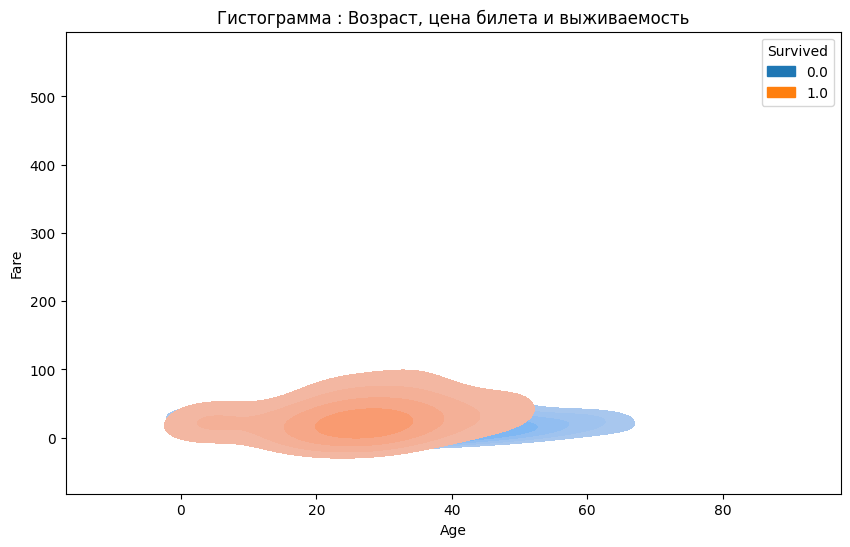

In [56]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='Age', y='Fare', hue='Survived', data=data, fill=True, thresh=0.2)

plt.title("Гистограмма : Возраст, цена билета и выживаемость")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

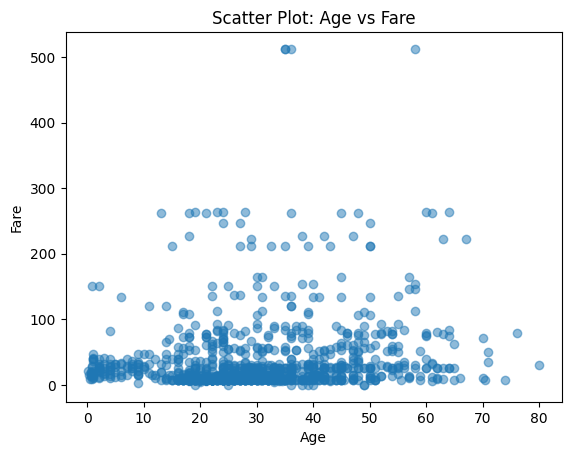

In [41]:
import matplotlib.pyplot as plt

plt.scatter(data['Age'], data['Fare'], alpha=0.5)
plt.title('Scatter Plot: Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


In [42]:
import plotly.express as px

fig = px.scatter_3d(data, x='Age', y='Fare', z='Relatives', color='Pclass')
fig.show()


In [51]:
# Linear plot: Средний стоимость  по классу и выживанию

fare_survival = data.groupby(['Pclass', 'Survived'], observed=True)['Fare'].mean().reset_index()

fig = px.line(
    fare_survival, x='Pclass', y='Fare',
    color='Survived',
    markers=True,
    title="Средний стоимость  по классу и выживанию"

)

fig.show()

In [46]:
fig = px.histogram(
    data, x='Age',
    title="Распределение возраста пассажиров"
)

fig.show()

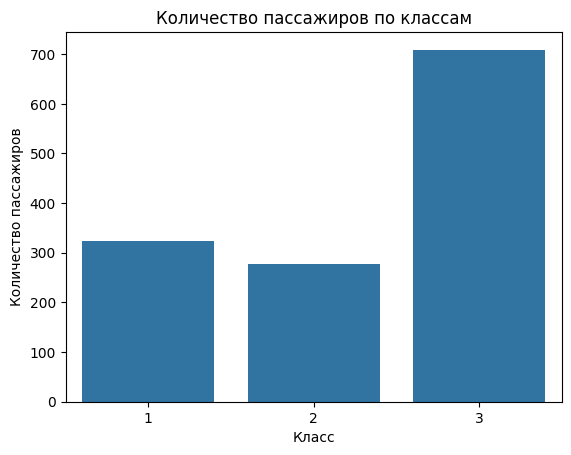

In [ ]:
# Bar chart: Количество пассажиров по классам
sns.barplot(x=data['Pclass'].value_counts().index, y=data['Pclass'].value_counts().values)
plt.title("Количество пассажиров по классам")
plt.xlabel("Класс")
plt.ylabel("Количество пассажиров")
plt.show()


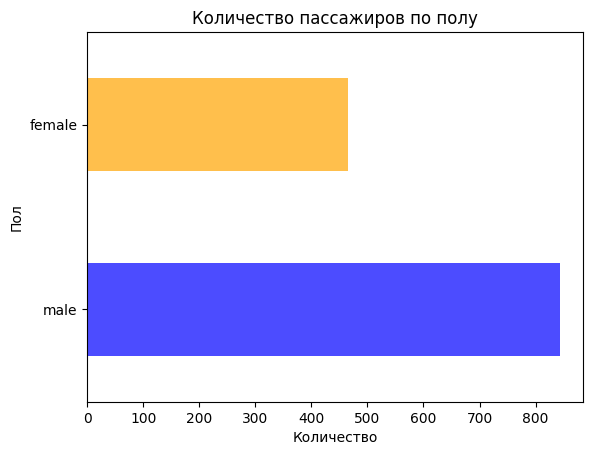

In [ ]:
# Horizontal Bar Chart: Количество пассажиров по полу
data['Sex'].value_counts().plot(kind='barh', color=['blue', 'orange'], alpha=0.7)
plt.title("Количество пассажиров по полу")
plt.xlabel("Количество")
plt.ylabel("Пол")
plt.show()


In [27]:
## Pie Chart: Выживаемость
survival_counts = data['Survived'].value_counts().reset_index()
survival_counts.columns = ['Survived', 'Count']

survival_counts['Status'] = survival_counts['Survived'].replace({0: 'Не выжил', 1: 'Выжил'})

fig = px.pie(
    survival_counts,
    values='Count',
    names='Status',
    title='"Доля выживших и погибших"'
)

fig.show()

<ipython-input-27-6266863db6ce>:5: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



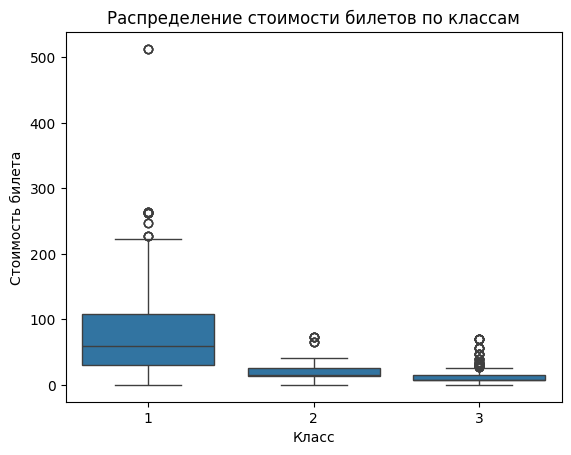

In [ ]:
# Box Chart: Стоимость билетов по классам
sns.boxplot(x=data['Pclass'], y=data['Fare'])
plt.title("Распределение стоимости билетов по классам")
plt.xlabel("Класс")
plt.ylabel("Стоимость билета")
plt.show()


In [25]:
# Make sure that there are no missing values in the key columns in the data
data = data[['Pclass', 'Sex', 'Survived']].dropna()

# Add tags for the survival status
data['Survival Status'] = data['Survived'].map({0: 'Died', 1: 'Survived'}).astype(str)

fig = px.sunburst(
    data,
    path=['Pclass', 'Sex', 'Survival Status'],  # Hierarchy to display
    title='Distribution of survivors and dead by class and gender on the Titanic'
)

fig.show()

/usr/local/lib/python3.11/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.11/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.11/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Доп

In [ ]:
import plotly.graph_objects as go

# Пример Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        label=['Мужчины', 'Женщины', 'Выжили', 'Не выжили'],
        pad=15,
        thickness=20
    ),
    link=dict(
        source=[0, 0, 1, 1],
        target=[2, 3, 2, 3],
        value=[data[(data['Sex'] == 'male') & (data['Survived'] == 1)].shape[0],
               data[(data['Sex'] == 'male') & (data['Survived'] == 0)].shape[0],
               data[(data['Sex'] == 'female') & (data['Survived'] == 1)].shape[0],
               data[(data['Sex'] == 'female') & (data['Survived'] == 0)].shape[0]]
    )
))

# Показываем график
fig.show()
